In [1]:
import os
import sys
import gc
from pathlib import Path
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# -----------------------
# project path setup
# -----------------------

PROJECT_ROOT_CANDIDATES = [
    Path("/home/ganchao/isilon/AllStaff/DCF"),
    Path("/home/ganchao/DCF"),
    Path("/home/ganchao"),
    Path.cwd(),
]

PROJECT_ROOT = None
for p in PROJECT_ROOT_CANDIDATES:
    if (p / "dnnlib").exists() and (p / "torch_utils").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Cannot find DCF repo root. Please set PROJECT_ROOT manually to the folder containing dnnlib/ and torch_utils/."
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())

# -----------------------
# standard imports
# -----------------------

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from tqdm.auto import tqdm

import dnnlib.util_v7 as util
from plot_sim_results_v7 import (
    read_model,
    generate_traj,
    proj_to_latent,
    latent_mu,
    plot_latent_time_series,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

# -----------------------
# analysis settings
# -----------------------

RUN_NAME = "auditory_U331_phee_ant_lag0_none"

FULL_DATA_DIR_CANDIDATES = [
    Path("/home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant"),
    Path("data/m96z_U331_phee_ant"),
]

FIT_DATA_DIR = Path("out/auditory/U331_phee_ant/dimk_lag0/t/none/data")

RUN_DIR = Path(
    "out/auditory/U331_phee_ant/dimk_lag0/t/none/"
    "00000-auditory_U331_phee_ant_lag0_none-prp-uncond-regularFM-gpus1-batch256-fp32"
)

CKPT_NAME = "network-snapshot-049674.pkl"

DT = 8.19e-4

DIM_TO_KEEP = 3
K_MAX_TO_SHOW = 32
K_TARGET = 20

SPECIFIC_TRIAL = 0
MAX_LINE_TRIALS = None
ENCODER_RMSE_MAX_TRIALS = None

TAU_LATENT = 0.0

RUN_TAU1_SIMULATION = True
RUN_TAU0_SIMULATION = True

SAVE_FIGS = True
PLOT_DIR = Path("paper_fig/auditory_U331_phee_ant_clean")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("plot dir:", PLOT_DIR)

PROJECT_ROOT: /home/ganchao/isilon/AllStaff/DCF
cwd: /home/ganchao/isilon/AllStaff/DCF
device: cuda
plot dir: paper_fig/auditory_U331_phee_ant_clean


# 1. Load Data

In [2]:
def to_list_of_arrays(x):
    if isinstance(x, list):
        return [np.asarray(a) for a in x]

    x = np.asarray(x, dtype=object)

    if x.dtype == object:
        return [np.asarray(a) for a in x.tolist()]

    if x.ndim == 3:
        return [x[i] for i in range(x.shape[0])]

    raise RuntimeError(f"Unsupported samples shape: {getattr(x, 'shape', None)}")


def load_samples_npz(path):
    arr = np.load(path, allow_pickle=True)["samples"]
    return [np.asarray(a, dtype=np.float32) for a in to_list_of_arrays(arr)]


def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(map(str, paths)))


def maybe_load_metadata(data_dir):
    meta_path = Path(data_dir) / "metadata.npy"
    if not meta_path.exists():
        return {}

    meta = np.load(meta_path, allow_pickle=True)
    if isinstance(meta, np.ndarray) and meta.shape == ():
        return meta.item()

    return {}


FULL_DATA_DIR = first_existing(FULL_DATA_DIR_CANDIDATES)

dset_samples_full = load_samples_npz(FULL_DATA_DIR / "dataset_samples.npz")
dset_samples = load_samples_npz(FIT_DATA_DIR / "dataset_samples.npz")
metadata = maybe_load_metadata(FULL_DATA_DIR)

print("full data dir:", FULL_DATA_DIR)
print("fit data dir:", FIT_DATA_DIR)
print("n_trial:", len(dset_samples))
print("full trial shape:", dset_samples_full[0].shape)
print("fit trial shape:", dset_samples[0].shape)
print("metadata keys:", sorted(metadata.keys()))

full data dir: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant
fit data dir: out/auditory/U331_phee_ant/dimk_lag0/t/none/data
n_trial: 5
full trial shape: (3406, 30)
fit trial shape: (3406, 30)
metadata keys: ['bad_channel_threshold_std', 'baseline_mean', 'baseline_window_ms', 'call_type', 'channel_std', 'duration_ms', 'format', 'good_ch', 'kept_channel_idx', 'original_time_ms', 'poststim', 'preprocessing', 'prestim', 'processed_shape', 'raw_filtered_shape', 'raw_shape', 'removed_channel_idx', 'sample_rate', 'smooth_sigma_bins', 'smooth_sigma_ms', 'stim_idx', 'time_ms', 'trim_start_bins', 'trim_start_ms', 'u_id', 'untrimmed_processed_shape', 'vocfile']


# 2. Load Model

In [3]:
flow_net, dyn_net, encoder, lag_from_model = read_model(str(RUN_DIR) + "/", "/" + CKPT_NAME)

flow_net = flow_net.to(device).eval()
dyn_net = dyn_net.to(device).eval()
encoder = encoder.to(device).eval()

lag_from_data = int(dset_samples_full[0].shape[0] - dset_samples[0].shape[0])
lag = lag_from_model if lag_from_model is not None else max(0, lag_from_data)

T_max = max(x.shape[0] for x in dset_samples)
D_obs = dset_samples[0].shape[1]
n_step = T_max

print("checkpoint:", RUN_DIR / CKPT_NAME)
print("lag_from_model:", lag_from_model)
print("lag_from_data:", lag_from_data)
print("using lag:", lag)
print("T_max:", T_max)
print("D_obs:", D_obs)


def compute_clamp_range(trials, eps=1e-1):
    T_max = max(arr.shape[0] for arr in trials)
    padded = [
        np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)), mode="constant", constant_values=np.nan)
        for arr in trials
    ]

    stacked = np.stack(padded, axis=0)

    lo = np.nanmin(stacked, axis=(0, 1))
    hi = np.nanmax(stacked, axis=(0, 1))

    cr = np.stack([lo, hi], axis=1)
    cr[:, 0] -= eps
    cr[:, 1] += eps

    return cr.astype(np.float32)


clamp_range = compute_clamp_range(dset_samples, eps=1e-1)

print("clamp_range shape:", clamp_range.shape)
print("first 5 clamp ranges:")
print(clamp_range[:5])

checkpoint: out/auditory/U331_phee_ant/dimk_lag0/t/none/00000-auditory_U331_phee_ant_lag0_none-prp-uncond-regularFM-gpus1-batch256-fp32/network-snapshot-049674.pkl
lag_from_model: None
lag_from_data: 0
using lag: 0
T_max: 3406
D_obs: 30
clamp_range shape: (30, 2)
first 5 clamp ranges:
[[-3.6509635  5.1920967]
 [-2.57559    5.5775995]
 [-4.5644336 12.078834 ]
 [-3.5830414  4.787847 ]
 [-4.2479277  8.083756 ]]


# 3. Some helper functions

In [4]:
def savefig(name):
    if SAVE_FIGS:
        path = PLOT_DIR / name
        plt.savefig(path)
        print("saved:", path)


def as_numpy_list(trajs):
    out = []
    for x in trajs:
        if hasattr(x, "detach"):
            x = x.detach().cpu().numpy()
        out.append(np.asarray(x))
    return out


def choose_trial_indices(n, max_n=None):
    if max_n is None or max_n >= n:
        return np.arange(n)
    return np.linspace(0, n - 1, max_n, dtype=int)


def average_traj(trajs):
    T = min(np.asarray(x).shape[0] for x in trajs)
    return np.stack([np.asarray(x)[:T] for x in trajs], axis=0).mean(axis=0)


def get_encoder_parts(encoder, example_trial, device):
    with torch.inference_mode():
        x = torch.as_tensor(example_trial[:1], device=device, dtype=torch.float32)
        mu, D, L, bias = encoder.encode(x, return_data_mean=True, update_stats=False)

    d_vec = torch.diagonal(D) if D.ndim == 2 else D.reshape(-1)
    K = int(min(getattr(encoder, "k_max", d_vec.numel()), d_vec.numel()))

    d_safe = torch.clamp(d_vec[:K], min=0)
    loading = L[:, :K] * torch.sqrt(d_safe).unsqueeze(0)

    return {
        "d_vec": d_vec.detach().cpu().numpy(),
        "L": L[:, :K].detach().cpu().numpy(),
        "loading": loading.detach().cpu().numpy(),
        "bias": bias.reshape(-1).detach().cpu().numpy(),
        "K": K,
    }


def encode_mu_trials(encoder, trials, dim_keep, device, trial_indices=None):
    if trial_indices is None:
        trial_indices = range(len(trials))

    mu_trajs = []
    encoder = encoder.to(device).eval()

    with torch.inference_mode():
        for i in tqdm(list(trial_indices), desc="encode μ"):
            x = torch.as_tensor(np.asarray(trials[i]), device=device, dtype=torch.float32)
            mu, _, _, _ = encoder.encode(x, return_data_mean=True, update_stats=False)
            mu_trajs.append(mu[:, :dim_keep].detach().cpu().numpy())

    return mu_trajs


def encoder_reconstruct_trials(encoder, trials, device, trial_indices=None):
    if trial_indices is None:
        trial_indices = range(len(trials))

    rec = {}
    encoder = encoder.to(device).eval()

    with torch.inference_mode():
        for i in tqdm(list(trial_indices), desc="encoder recon"):
            x = torch.as_tensor(np.asarray(trials[i]), device=device, dtype=torch.float32)
            xhat = encoder.rsample(x)

            if isinstance(xhat, tuple):
                xhat = xhat[0]

            rec[int(i)] = xhat.detach().cpu().numpy()

    return rec


def plot_trial_heatmaps(rows, row_names, trial_idx, title, cmap="gray_r"):
    vals = [np.asarray(r[trial_idx]) for r in rows]
    n = len(vals)

    is_error = np.array(["error" in name.lower() for name in row_names])

    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n), constrained_layout=True)
    axes = np.atleast_1d(axes)

    # Shared scale for non-error rows
    normal_vals = [v for v, flag in zip(vals, is_error) if not flag]
    vmin = min(float(v.min()) for v in normal_vals)
    vmax = max(float(v.max()) for v in normal_vals)

    im_normal = None
    im_error = None
    error_axes = []

    for ax, arr, name, flag in zip(axes, vals, row_names, is_error):
        if flag:
            emax = float(np.nanmax(np.abs(arr)))
            im = ax.imshow(
                arr.T,
                aspect="auto",
                origin="lower",
                cmap="seismic",
                vmin=-emax,
                vmax=emax,
            )
            im_error = im
            error_axes.append(ax)
        else:
            im = ax.imshow(
                arr.T,
                aspect="auto",
                origin="lower",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
            im_normal = im

        ax.set_ylabel("channel")
        ax.set_title(name)

    axes[-1].set_xlabel("time bin")

    if im_normal is not None:
        normal_axes = [ax for ax, flag in zip(axes, is_error) if not flag]
        fig.colorbar(im_normal, ax=normal_axes, shrink=0.85, label="value")

    if im_error is not None:
        fig.colorbar(im_error, ax=error_axes, shrink=0.85, label="error")

    fig.suptitle(title)

    return fig


def plot_specific_and_mean_3d(
    mu_trajs,
    trial_idx=0,
    dims=(0, 1, 2),
    title_prefix="",
    z_scale="auto",
    elev_azim=None,
):
    specific = np.asarray(mu_trajs[trial_idx])
    mean_tr = average_traj(mu_trajs)

    trajs = [specific, mean_tr]
    names = [f"trial {trial_idx}", "trial average"]

    xyzs = [tr[:, list(dims)].copy() for tr in trajs]

    if z_scale == "auto":
        all_xyz = np.concatenate(xyzs, axis=0)
        xr = np.ptp(all_xyz[:, 0])
        yr = np.ptp(all_xyz[:, 1])
        zr = np.ptp(all_xyz[:, 2])
        scale = ((xr + yr) / 2.0) / zr if zr > 0 else 1.0
    elif z_scale == "none":
        scale = 1.0
    else:
        scale = float(z_scale)

    for xyz in xyzs:
        xyz[:, 2] *= scale

    fig = plt.figure(figsize=(10, 4.8), constrained_layout=True)

    for j, (xyz, name) in enumerate(zip(xyzs, names), start=1):
        ax = fig.add_subplot(1, 2, j, projection="3d")

        t = np.arange(xyz.shape[0])

        if xyz.shape[0] > 1:
            segs = np.stack([xyz[:-1], xyz[1:]], axis=1)
            lc = Line3DCollection(segs, cmap=plt.get_cmap(), linewidth=2)
            lc.set_array(t[1:])
            ax.add_collection3d(lc)

        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=t, s=10, cmap=plt.get_cmap())
        ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=40, edgecolor="k")

        ax.set_xlabel(f"μ{dims[0] + 1}")
        ax.set_ylabel(f"μ{dims[1] + 1}")
        ax.set_zlabel(f"μ{dims[2] + 1}" + (f" × {scale:.2g}" if scale != 1.0 else ""))

        ax.set_title(name)

        lo = xyz.min(axis=0)
        hi = xyz.max(axis=0)
        pad = 0.03 * np.maximum(hi - lo, 1e-12)

        ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
        ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
        ax.set_zlim(lo[2] - pad[2], hi[2] + pad[2])

        try:
            ax.set_box_aspect((1, 1, 1))
        except Exception:
            pass

        if elev_azim is not None:
            ax.view_init(*elev_azim)

    fig.suptitle(title_prefix)

    return fig

In [5]:
def slice_trajs_by_time(trajs, start_T=0, end_T=None):
    out = []
    for x in trajs:
        x = np.asarray(x)
        if end_T is None:
            end = x.shape[0]
        else:
            end = min(end_T, x.shape[0])
        out.append(x[start_T:end])
    return out


def plot_specific_and_mean_3d_with_colorbar(
    mu_trajs,
    trial_idx=0,
    dims=(0, 1, 2),
    title_prefix="",
    z_scale="auto",
    start_T=0,
    end_T=None,
):
    mu_trajs = slice_trajs_by_time(mu_trajs, start_T=start_T, end_T=end_T)

    specific = np.asarray(mu_trajs[trial_idx])
    mean_tr = average_traj(mu_trajs)

    trajs = [specific, mean_tr]
    names = [f"trial {trial_idx}", "trial average"]

    xyzs = [tr[:, list(dims)].copy() for tr in trajs]

    if z_scale == "auto":
        all_xyz = np.concatenate(xyzs, axis=0)
        xr = np.ptp(all_xyz[:, 0])
        yr = np.ptp(all_xyz[:, 1])
        zr = np.ptp(all_xyz[:, 2])
        scale = ((xr + yr) / 2.0) / zr if zr > 0 else 1.0
    elif z_scale == "none":
        scale = 1.0
    else:
        scale = float(z_scale)

    for xyz in xyzs:
        xyz[:, 2] *= scale

    fig = plt.figure(figsize=(10, 4.8), constrained_layout=True)

    cmap = plt.get_cmap()
    t0 = start_T
    t1 = start_T + max(x.shape[0] for x in xyzs) - 1
    norm = Normalize(vmin=t0, vmax=t1)

    for j, (xyz, name) in enumerate(zip(xyzs, names), start=1):
        ax = fig.add_subplot(1, 2, j, projection="3d")

        t = np.arange(start_T, start_T + xyz.shape[0])

        if xyz.shape[0] > 1:
            segs = np.stack([xyz[:-1], xyz[1:]], axis=1)
            lc = Line3DCollection(segs, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(t[1:])
            ax.add_collection3d(lc)

        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=t, s=10, cmap=cmap, norm=norm)
        ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=45, edgecolor="k")

        ax.set_xlabel(f"μ{dims[0] + 1}")
        ax.set_ylabel(f"μ{dims[1] + 1}")
        ax.set_zlabel(f"μ{dims[2] + 1}" + (f" × {scale:.2g}" if scale != 1.0 else ""))
        ax.set_title(name)

        lo = xyz.min(axis=0)
        hi = xyz.max(axis=0)
        pad = 0.03 * np.maximum(hi - lo, 1e-12)

        ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
        ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
        ax.set_zlim(lo[2] - pad[2], hi[2] + pad[2])

        try:
            ax.set_box_aspect((1, 1, 1))
        except Exception:
            pass

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, shrink=0.75, pad=0.04, label="time bin")

    fig.suptitle(title_prefix)

    return fig

# 4. Encoder Check

encoder recon:   0%|          | 0/1 [00:00<?, ?it/s]

trial 0 encoder reconstruction RMSE: 0.4492
trial 0 encoder reconstruction relative RMSE: 0.4845
saved: paper_fig/auditory_U331_phee_ant_clean/01_encoder_check_heatmaps.png


encoder recon:   0%|          | 0/5 [00:00<?, ?it/s]

RMSE mean ± sd: 0.457765 0.006931389
relative RMSE mean ± sd: 0.4568618314433001 0.015118300556920311


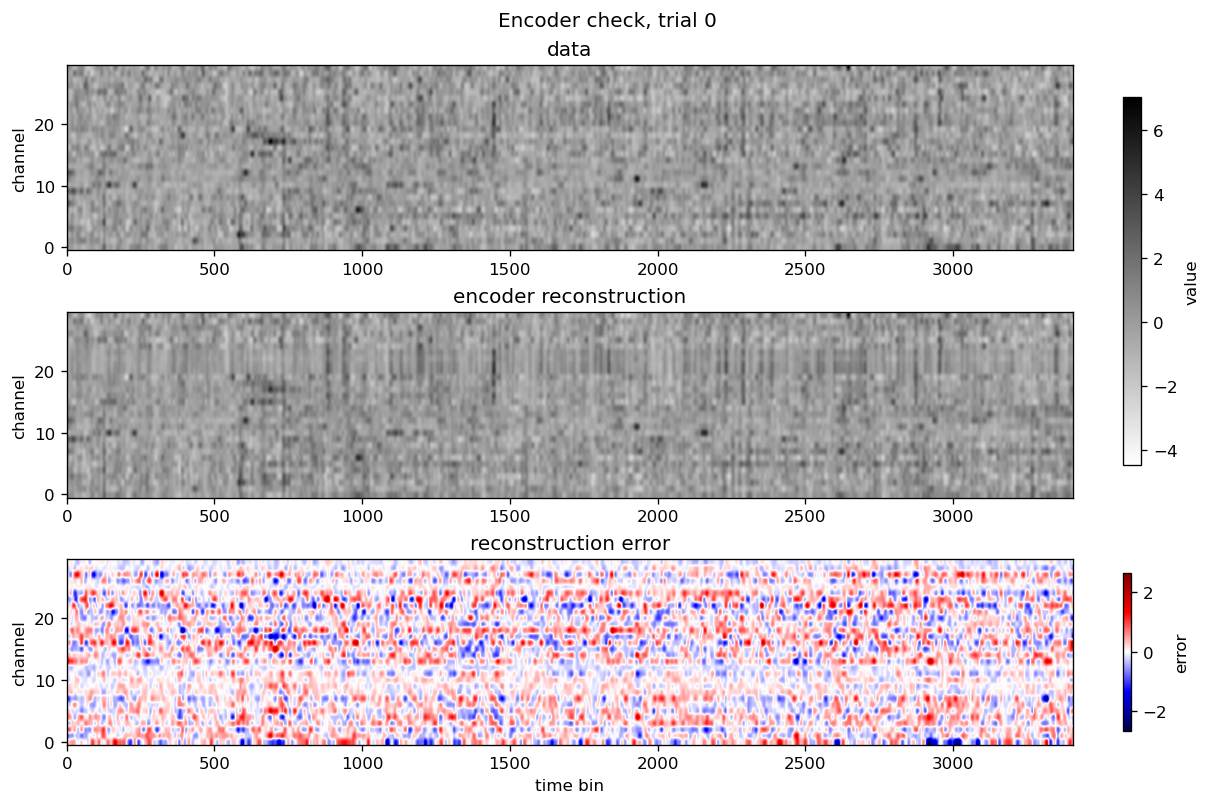

In [6]:
trial_idx = SPECIFIC_TRIAL
x = dset_samples[trial_idx]

rec_dict = encoder_reconstruct_trials(encoder, dset_samples, device, trial_indices=[trial_idx])
xhat = rec_dict[trial_idx]

err = xhat - x

rmse = float(np.sqrt(np.mean(err ** 2)))
rel_rmse = float(np.linalg.norm(err) / (np.linalg.norm(x) + 1e-12))

print(f"trial {trial_idx} encoder reconstruction RMSE: {rmse:.4g}")
print(f"trial {trial_idx} encoder reconstruction relative RMSE: {rel_rmse:.4g}")

fig = plot_trial_heatmaps(
    rows=[{trial_idx: x}, {trial_idx: xhat}, {trial_idx: err}],
    row_names=["data", "encoder reconstruction", "reconstruction error"],
    trial_idx=trial_idx,
    title=f"Encoder check, trial {trial_idx}",
)

savefig("01_encoder_check_heatmaps.png")


rmse_indices = choose_trial_indices(len(dset_samples), ENCODER_RMSE_MAX_TRIALS)
rec_all = encoder_reconstruct_trials(encoder, dset_samples, device, trial_indices=rmse_indices)

rmse_all = []
rel_rmse_all = []

for i in rmse_indices:
    i = int(i)

    x = np.asarray(dset_samples[i])
    xhat = rec_all[i]

    e = xhat - x

    rmse_all.append(np.sqrt(np.mean(e ** 2)))
    rel_rmse_all.append(np.linalg.norm(e) / (np.linalg.norm(x) + 1e-12))

rmse_all = np.asarray(rmse_all)
rel_rmse_all = np.asarray(rel_rmse_all)

print("RMSE mean ± sd:", rmse_all.mean(), rmse_all.std())
print("relative RMSE mean ± sd:", rel_rmse_all.mean(), rel_rmse_all.std())

# fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

# axes[0].hist(rmse_all, bins=30)
# axes[0].set_title("encoder RMSE")
# axes[0].set_xlabel("RMSE")
# axes[0].set_ylabel("trial count")

# axes[1].hist(rel_rmse_all, bins=30)
# axes[1].set_title("encoder relative RMSE")
# axes[1].set_xlabel("relative RMSE")

# savefig("02_encoder_check_rmse_hist.png")

encode μ:   0%|          | 0/5 [00:00<?, ?it/s]

encoder K: 30
diagnostic dim: 30
K_eff by 95% cumulative d within shown dims: 18
μ diagnostic shape: (17030, 30)


Text(0.5, 0.98, 'Encoder diagnostic')

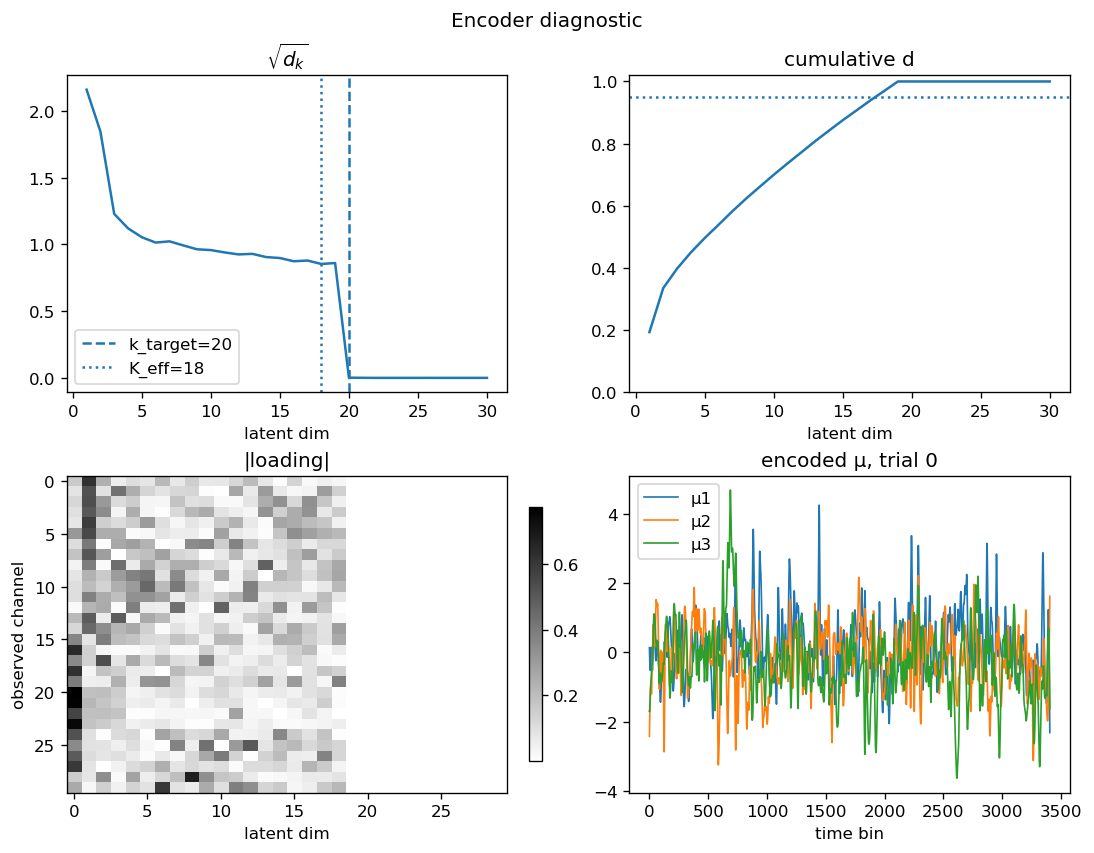

In [7]:
enc_parts = get_encoder_parts(encoder, dset_samples[0], device)

d_np = enc_parts["d_vec"]
loading_np = enc_parts["loading"]
K_enc = enc_parts["K"]

diag_dim = int(min(K_MAX_TO_SHOW, K_enc))

d_head = np.maximum(d_np[:diag_dim], 0)
cum = np.cumsum(d_head)

K_eff = int(np.searchsorted(cum, 0.95 * cum[-1]) + 1) if cum[-1] > 0 else 0

mu_diag = encode_mu_trials(encoder, dset_samples, dim_keep=diag_dim, device=device)
mu_diag_all = np.concatenate(mu_diag, axis=0)

print("encoder K:", K_enc)
print("diagnostic dim:", diag_dim)
print("K_eff by 95% cumulative d within shown dims:", K_eff)
print("μ diagnostic shape:", mu_diag_all.shape)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)

axes[0, 0].plot(np.arange(1, diag_dim + 1), np.sqrt(d_head))
axes[0, 0].axvline(K_TARGET, linestyle="--", label=f"k_target={K_TARGET}")

if K_eff > 0:
    axes[0, 0].axvline(K_eff, linestyle=":", label=f"K_eff={K_eff}")

axes[0, 0].set_title(r"$\sqrt{d_k}$")
axes[0, 0].set_xlabel("latent dim")
axes[0, 0].legend()

if cum[-1] > 0:
    axes[0, 1].plot(np.arange(1, diag_dim + 1), cum / cum[-1])

axes[0, 1].axhline(0.95, linestyle=":")
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].set_title("cumulative d")
axes[0, 1].set_xlabel("latent dim")

im = axes[1, 0].imshow(np.abs(loading_np[:, :diag_dim]), aspect="auto", cmap="gray_r")
axes[1, 0].set_title("|loading|")
axes[1, 0].set_xlabel("latent dim")
axes[1, 0].set_ylabel("observed channel")
fig.colorbar(im, ax=axes[1, 0], shrink=0.8)

for k in range(min(DIM_TO_KEEP, diag_dim)):
    axes[1, 1].plot(mu_diag[SPECIFIC_TRIAL][:, k], lw=1, label=f"μ{k + 1}")

axes[1, 1].set_title(f"encoded μ, trial {SPECIFIC_TRIAL}")
axes[1, 1].set_xlabel("time bin")
axes[1, 1].legend()

fig.suptitle("Encoder diagnostic")

# savefig("03_encoder_diagnostic.png")

# 6. Flowed Latent

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 31.51it/s]


plot window: 0 3406
flowed state example shape: (3406, 30)
flowed μ example shape: (3406, 3)
saved: paper_fig/auditory_U331_phee_ant_clean/04_flowed_latent_timeseries.png


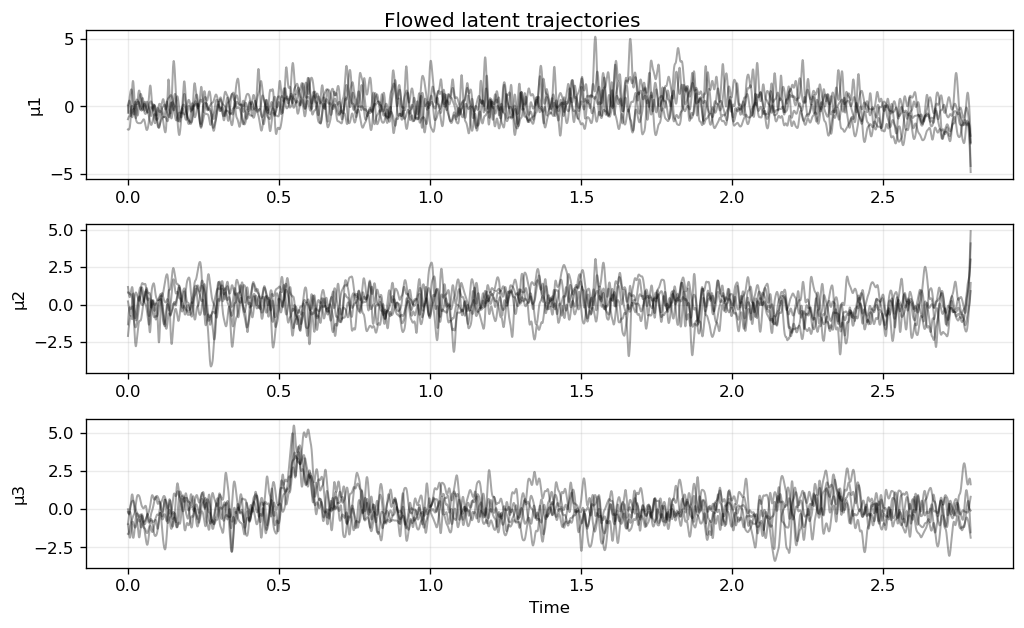

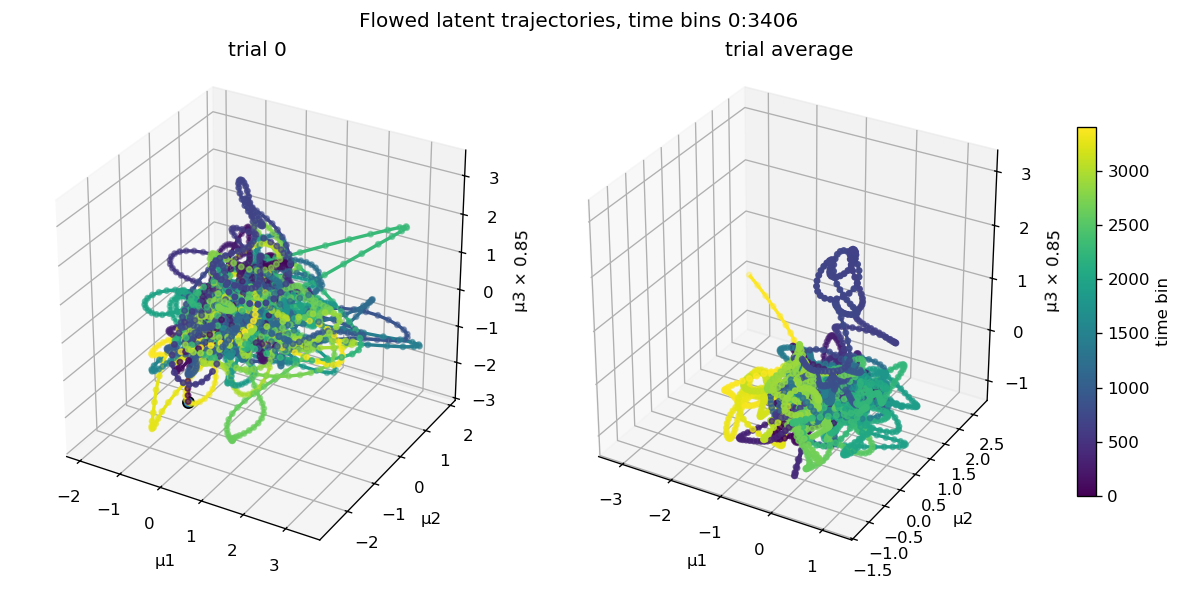

In [8]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

latent_flow_states = proj_to_latent(dset_samples, flow_net, TAU_LATENT, device)

mu_flow_tensors, _, _, _, _ = latent_mu(
    latent_flow_states,
    encoder,
    DIM_TO_KEEP,
    device,
    fullRes=True,
    resid_tol=1e-15,
)

mu_flow = as_numpy_list(mu_flow_tensors)

T_flow = min(x.shape[0] for x in mu_flow)
start_T = 0
end_T = T_flow

mu_flow_win = slice_trajs_by_time(mu_flow, start_T=start_T, end_T=end_T)

print("plot window:", start_T, end_T)



print("flowed state example shape:", latent_flow_states[0].shape)
print("flowed μ example shape:", mu_flow[0].shape)


plot_trials = choose_trial_indices(len(mu_flow), MAX_LINE_TRIALS)

plot_latent_time_series(
    mu_flow_win,
    dims=np.arange(DIM_TO_KEEP),
    trial_indices=plot_trials,
    dt=DT,
    alpha=0.35,
    fig_w=9,
    fig_h_per=1.8,
)

plt.suptitle("Flowed latent trajectories")
savefig("04_flowed_latent_timeseries.png")


fig = plot_specific_and_mean_3d_with_colorbar(
    mu_flow,
    trial_idx=SPECIFIC_TRIAL,
    dims=(0, 1, 2),
    title_prefix=f"Flowed latent trajectories, time bins {start_T}:{end_T}",
    z_scale="auto",
    start_T=start_T,
    end_T=end_T,
)

# savefig("05_flowed_latent_3d_specific_and_mean.png")

In [9]:
# # Another time window for flowed latent trajectories

# start_T = 0
# end_T = T_flow // 2
# # example above: third quarter of the recording
# # change these two lines however you want

# mu_flow_win = slice_trajs_by_time(mu_flow, start_T=start_T, end_T=end_T)

# print("plot window:", start_T, end_T)

# plot_trials = choose_trial_indices(len(mu_flow), MAX_LINE_TRIALS)

# plot_latent_time_series(
#     mu_flow_win,
#     dims=np.arange(DIM_TO_KEEP),
#     trial_indices=plot_trials,
#     dt=DT,
#     alpha=0.35,
#     fig_w=9,
#     fig_h_per=1.8,
# )

# plt.suptitle(f"Flowed latent trajectories, time bins {start_T}:{end_T}")
# savefig(f"04_flowed_latent_timeseries_{start_T}_{end_T}.png")


# fig = plot_specific_and_mean_3d_with_colorbar(
#     mu_flow,
#     trial_idx=SPECIFIC_TRIAL,
#     dims=(0, 1, 2),
#     title_prefix=f"Flowed latent trajectories, time bins {start_T}:{end_T}",
#     z_scale="auto",
#     start_T=start_T,
#     end_T=end_T,
# )

# # savefig(f"05_flowed_latent_3d_specific_and_mean_{start_T}_{end_T}.png")

# 7. Simulated Traj

100%|██████████████████████████████████████| 3405/3405 [00:19<00:00, 171.84it/s]


traj_sim_tau1 example shape: (3406, 30)


100%|██████████████████████████████████████| 3405/3405 [00:19<00:00, 175.06it/s]


traj_sim_tau0 example shape: (3406, 30)
saved: paper_fig/auditory_U331_phee_ant_clean/06_sim_tau1_heatmaps.png


100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 57.16it/s]


saved: paper_fig/auditory_U331_phee_ant_clean/07_tau0_state_comparison_heatmaps.png
simulated μ example shape: (3406, 3)


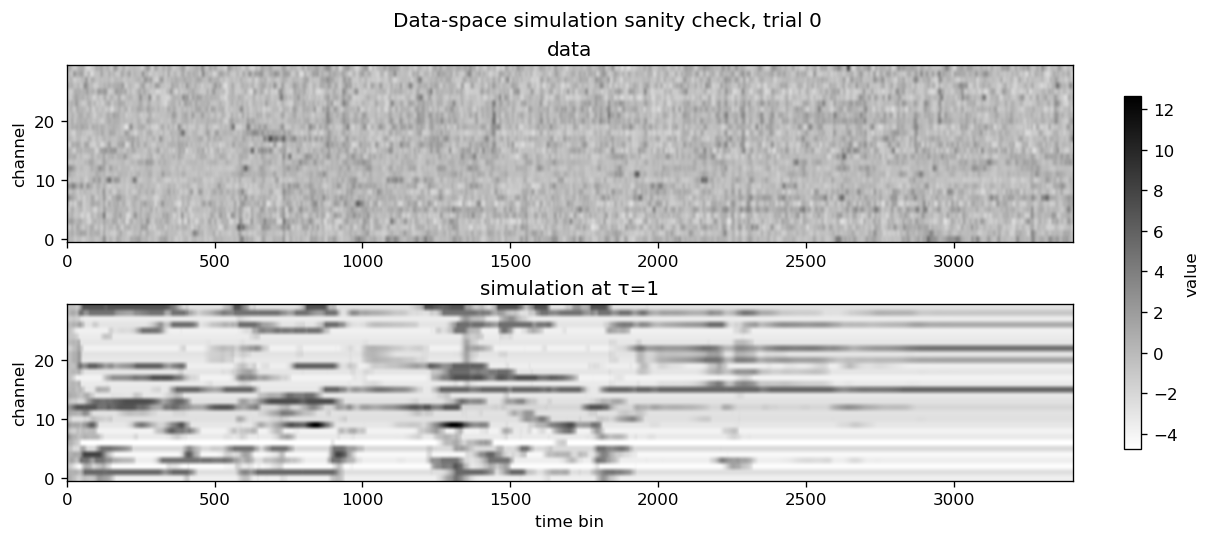

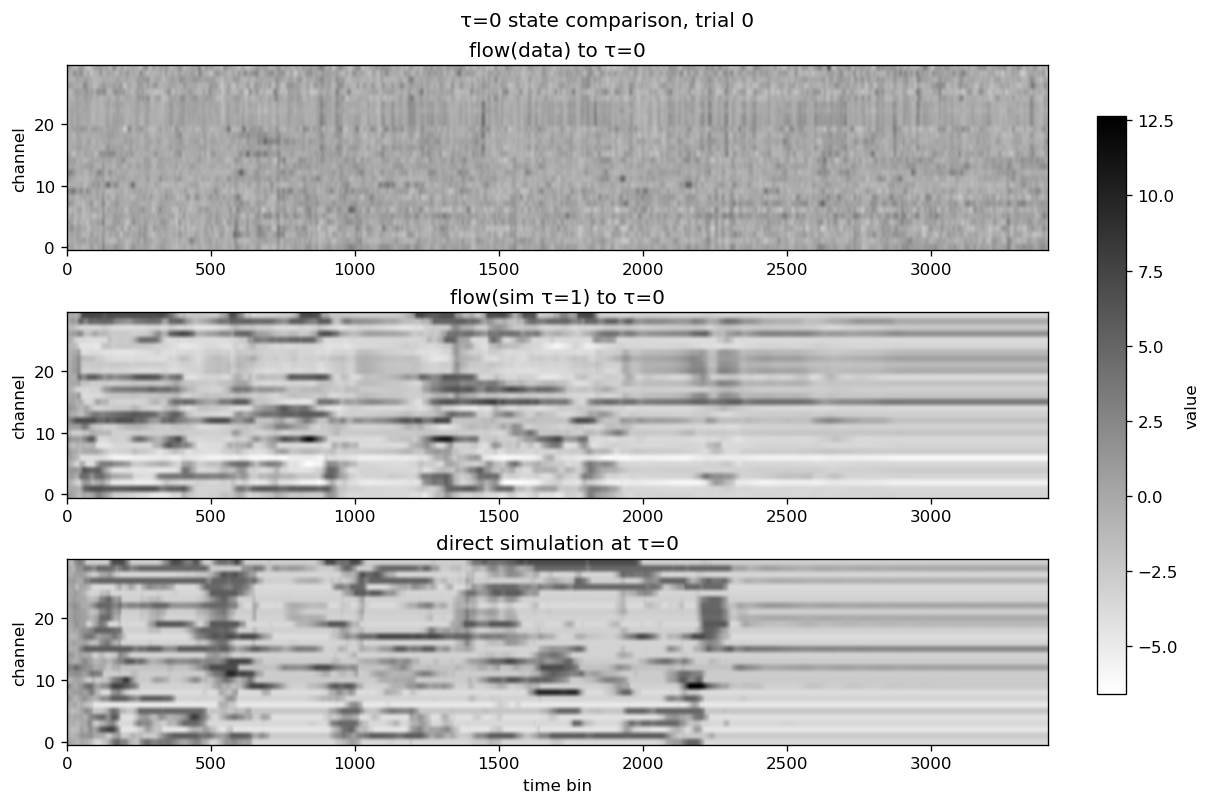

In [10]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if RUN_TAU1_SIMULATION:
    traj_sim_tau1, lag_cov_tau1 = generate_traj(
        dyn_net=dyn_net,
        dset_samples=dset_samples,
        n_step=n_step,
        tau=1.0,
        device=device,
        lag=lag,
        include_x0_tau=False,
        oracle=False,
        flow_net=None,
        clamp_range=clamp_range,
        dset_samples_full=dset_samples_full,
    )

    print("traj_sim_tau1 example shape:", traj_sim_tau1[0].shape)


if RUN_TAU0_SIMULATION:
    traj_sim_tau0, lag_cov_tau0 = generate_traj(
        dyn_net=dyn_net,
        dset_samples=dset_samples,
        n_step=n_step,
        tau=0.0,
        device=device,
        lag=lag,
        include_x0_tau=False,
        oracle=False,
        flow_net=flow_net,
        clamp_range=clamp_range,
        dset_samples_full=dset_samples_full,
    )

    print("traj_sim_tau0 example shape:", traj_sim_tau0[0].shape)


if RUN_TAU1_SIMULATION:
    fig = plot_trial_heatmaps(
        rows=[dset_samples, traj_sim_tau1],
        row_names=["data", "simulation at τ=1"],
        trial_idx=SPECIFIC_TRIAL,
        title=f"Data-space simulation sanity check, trial {SPECIFIC_TRIAL}",
    )

    savefig("06_sim_tau1_heatmaps.png")


if RUN_TAU1_SIMULATION and RUN_TAU0_SIMULATION:
    traj_sim_tau1_to_tau0 = proj_to_latent(traj_sim_tau1, flow_net, TAU_LATENT, device)

    fig = plot_trial_heatmaps(
        rows=[latent_flow_states, traj_sim_tau1_to_tau0, traj_sim_tau0],
        row_names=["flow(data) to τ=0", "flow(sim τ=1) to τ=0", "direct simulation at τ=0"],
        trial_idx=SPECIFIC_TRIAL,
        title=f"τ=0 state comparison, trial {SPECIFIC_TRIAL}",
    )

    savefig("07_tau0_state_comparison_heatmaps.png")


mu_sim_tensors = latent_mu(
    traj_sim_tau0,
    encoder,
    DIM_TO_KEEP,
    device,
    fullRes=False,
    resid_tol=1e-15,
)

mu_sim = as_numpy_list(mu_sim_tensors)

print("simulated μ example shape:", mu_sim[0].shape)


simulated plot window: 0 3406


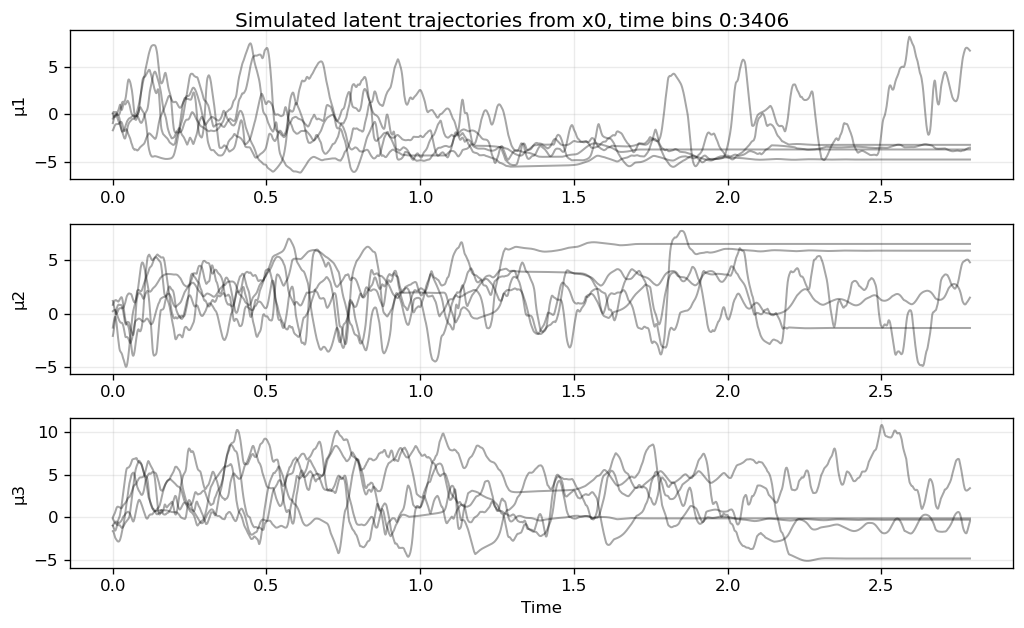

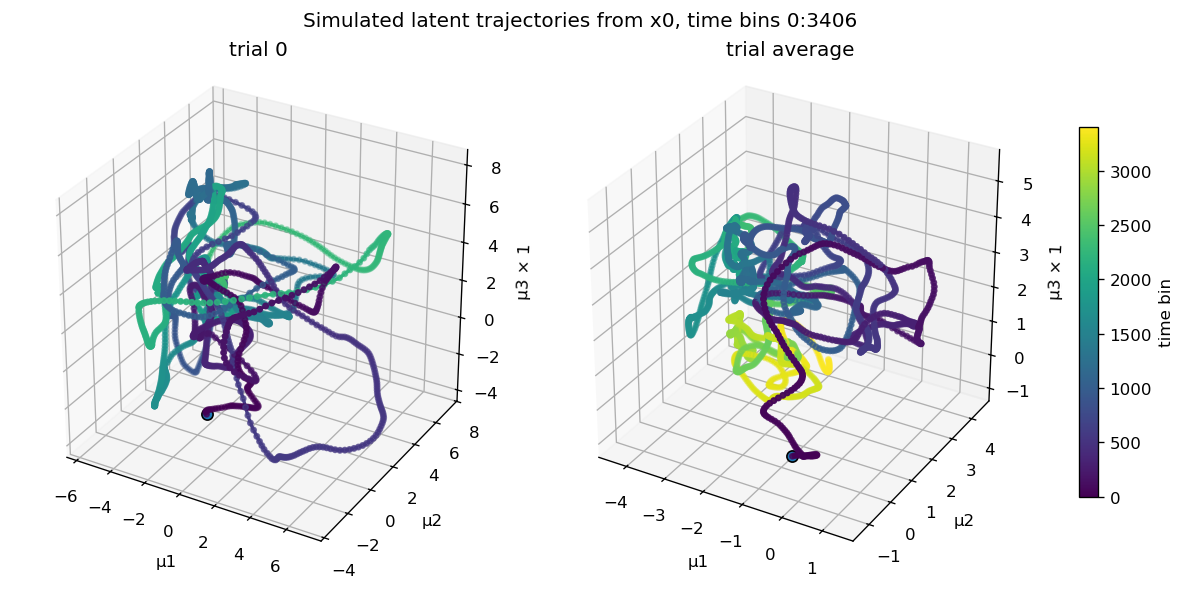

In [11]:
# windowed simulated latent trajectory plots

T_sim = min(x.shape[0] for x in mu_sim)

start_T_sim = 0
end_T_sim = T_sim

mu_sim_win = slice_trajs_by_time(mu_sim, start_T=start_T_sim, end_T=end_T_sim)

print("simulated plot window:", start_T_sim, end_T_sim)

plot_trials = choose_trial_indices(len(mu_sim), MAX_LINE_TRIALS)

plot_latent_time_series(
    mu_sim_win,
    dims=np.arange(DIM_TO_KEEP),
    trial_indices=plot_trials,
    dt=DT,
    alpha=0.35,
    fig_w=9,
    fig_h_per=1.8,
)

plt.suptitle(f"Simulated latent trajectories from x0, time bins {start_T_sim}:{end_T_sim}")
# savefig(f"08_simulated_latent_timeseries_{start_T_sim}_{end_T_sim}.png")


fig = plot_specific_and_mean_3d_with_colorbar(
    mu_sim,
    trial_idx=SPECIFIC_TRIAL,
    dims=(0, 1, 2),
    title_prefix=f"Simulated latent trajectories from x0, time bins {start_T_sim}:{end_T_sim}",
    z_scale="auto",
    start_T=start_T_sim,
    end_T=end_T_sim,
)

# savefig(f"09_simulated_latent_3d_specific_and_mean_{start_T_sim}_{end_T_sim}.png")

# 8. Some summary

saved: paper_fig/auditory_U331_phee_ant_clean/10_flowed_vs_simulated_mean_timeseries_0_3406.png


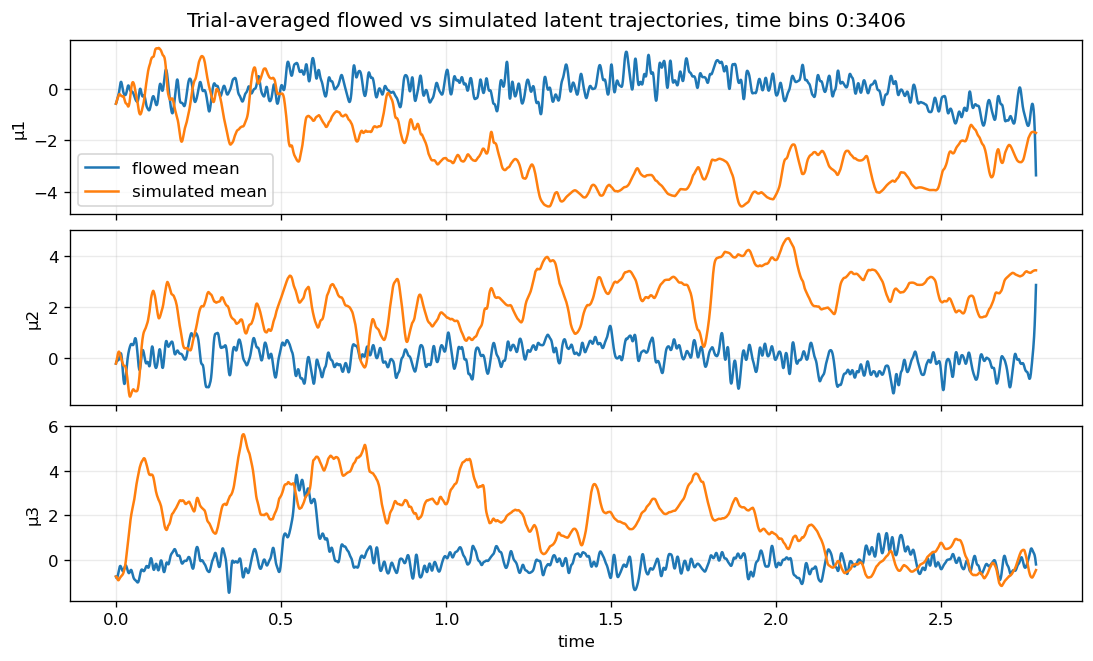

In [12]:
# Windowed summary: trial-averaged flowed vs simulated latent trajectories

mean_flow_full = average_traj(mu_flow)
mean_sim_full = average_traj(mu_sim)

T_summary = min(mean_flow_full.shape[0], mean_sim_full.shape[0])

start_T_sum = 0
end_T_sum = T_summary
# change these two lines as needed

mean_flow = mean_flow_full[start_T_sum:end_T_sum]
mean_sim = mean_sim_full[start_T_sum:end_T_sum]

mean_diff = mean_sim - mean_flow

fig, axes = plt.subplots(
    DIM_TO_KEEP,
    1,
    figsize=(9, 1.8 * DIM_TO_KEEP),
    sharex=True,
    constrained_layout=True,
)

axes = np.atleast_1d(axes)

time = np.arange(start_T_sum, end_T_sum) * DT

for k, ax in enumerate(axes):
    ax.plot(time, mean_flow[:, k], label="flowed mean")
    ax.plot(time, mean_sim[:, k], label="simulated mean")
    ax.set_ylabel(f"μ{k + 1}")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("time")
axes[0].legend()

fig.suptitle(f"Trial-averaged flowed vs simulated latent trajectories, time bins {start_T_sum}:{end_T_sum}")

savefig(f"10_flowed_vs_simulated_mean_timeseries_{start_T_sum}_{end_T_sum}.png")

# print("mean latent RMSE over window:", np.sqrt(np.mean(mean_diff ** 2, axis=0)))

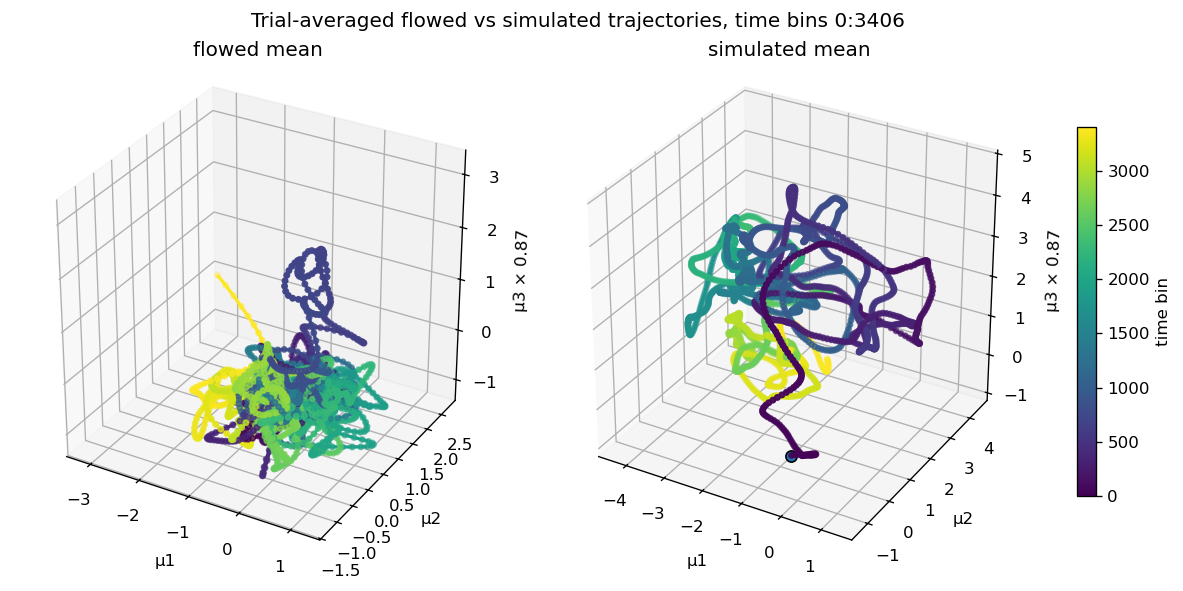

In [13]:
# 3D summary: trial-averaged flowed vs simulated trajectories

def plot_two_mean_3d_with_colorbar(
    mean_a,
    mean_b,
    name_a="flowed mean",
    name_b="simulated mean",
    dims=(0, 1, 2),
    title_prefix="",
    z_scale="auto",
    start_T=0,
):
    trajs = [np.asarray(mean_a)[:, list(dims)].copy(), np.asarray(mean_b)[:, list(dims)].copy()]
    names = [name_a, name_b]

    if z_scale == "auto":
        all_xyz = np.concatenate(trajs, axis=0)
        xr = np.ptp(all_xyz[:, 0])
        yr = np.ptp(all_xyz[:, 1])
        zr = np.ptp(all_xyz[:, 2])
        scale = ((xr + yr) / 2.0) / zr if zr > 0 else 1.0
    elif z_scale == "none":
        scale = 1.0
    else:
        scale = float(z_scale)

    for xyz in trajs:
        xyz[:, 2] *= scale

    fig = plt.figure(figsize=(10, 4.8), constrained_layout=True)

    cmap = plt.get_cmap()
    t = np.arange(start_T, start_T + trajs[0].shape[0])
    norm = Normalize(vmin=t[0], vmax=t[-1])

    for j, (xyz, name) in enumerate(zip(trajs, names), start=1):
        ax = fig.add_subplot(1, 2, j, projection="3d")

        if xyz.shape[0] > 1:
            segs = np.stack([xyz[:-1], xyz[1:]], axis=1)
            lc = Line3DCollection(segs, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(t[1:])
            ax.add_collection3d(lc)

        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=t, s=10, cmap=cmap, norm=norm)
        ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=45, edgecolor="k")

        ax.set_xlabel(f"μ{dims[0] + 1}")
        ax.set_ylabel(f"μ{dims[1] + 1}")
        ax.set_zlabel(f"μ{dims[2] + 1}" + (f" × {scale:.2g}" if scale != 1.0 else ""))
        ax.set_title(name)

        lo = xyz.min(axis=0)
        hi = xyz.max(axis=0)
        pad = 0.03 * np.maximum(hi - lo, 1e-12)

        ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
        ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
        ax.set_zlim(lo[2] - pad[2], hi[2] + pad[2])

        try:
            ax.set_box_aspect((1, 1, 1))
        except Exception:
            pass

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, shrink=0.75, pad=0.04, label="time bin")

    fig.suptitle(title_prefix)

    return fig


fig = plot_two_mean_3d_with_colorbar(
    mean_flow,
    mean_sim,
    name_a="flowed mean",
    name_b="simulated mean",
    dims=(0, 1, 2),
    title_prefix=f"Trial-averaged flowed vs simulated trajectories, time bins {start_T_sum}:{end_T_sum}",
    z_scale="auto",
    start_T=start_T_sum,
)

# savefig(f"11_flowed_vs_simulated_mean_3d_{start_T_sum}_{end_T_sum}.png")